# Environment catalogue

What MuJoCo Playground gives us to work with: which environments are
registered, which robot models they are built on, and how they are
configured by default.


In [1]:
import pandas as pd

from rl_locomotion.envs import registry as reg

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)


## The three suites - dm_control_suite, locomotion, and control_suite

Playground contains three families. Only `locomotion` is relevant to this
project!


In [2]:
envs = reg.envs_table()
print(f"{len(envs)} registered environments")
envs.groupby("suite").size().to_frame("n_envs")


54 registered environments


,n_envs
suite,
dm_control_suite,25
locomotion,19
manipulation,10


## Locomotion environments

Explanations of some columns:

- **`ctrl_dt` / `sim_dt`** - the policy acts every `ctrl_dt`, the physics
  integrates every `sim_dt`. Their ratio (`sim_steps_per_ctrl`) is how many
  physics steps each action costs.
- **`episode_s` / `episode length`** - episode length in simulated seconds rather than steps,
  which makes envs with different `ctrl_dt` comparable.
- **`has_domain_randomizer`** - whether Playground ships a randomizer for
  this env.


In [3]:
loco = reg.envs_table("locomotion")
loco[[
    "platform", "task", "ctrl_dt", "sim_dt", "sim_steps_per_ctrl",
    "episode_length", "episode_s", "has_domain_randomizer",
]]


,platform,task,ctrl_dt,sim_dt,sim_steps_per_ctrl,episode_length,episode_s,has_domain_randomizer
name,,,,,,,,
ApolloJoystickFlatTerrain,apollo,joystick,0.02,0.005,4,1000,20.0,False
BarkourJoystick,barkour,joystick,0.02,0.004,5,1000,20.0,False
BerkeleyHumanoidJoystickFlatTerrain,berkeley_humanoid,joystick,0.02,0.002,10,1000,20.0,True
BerkeleyHumanoidJoystickRoughTerrain,berkeley_humanoid,joystick,0.02,0.002,10,1000,20.0,True
G1JoystickFlatTerrain,g1,joystick,0.02,0.002,10,1000,20.0,True
G1JoystickRoughTerrain,g1,joystick,0.02,0.002,10,1000,20.0,True
Go1Footstand,go1,handstand,0.02,0.004,5,500,10.0,True
Go1Getup,go1,getup,0.02,0.004,5,300,6.0,True
Go1Handstand,go1,handstand,0.02,0.004,5,500,10.0,True


As we can see, there are 19 different locomotion environments, with different robots and different tasks. There are 9 different robots. Possible tasks are: joystick, handstand, getup, inplace_gait_tracking, joystick_gait_tracking.

## Robot models

Each environment is a *task* layered on a *robot model*. Several tasks
usually share one robot.

`n_xmls` counts the task scene files and helper, builder files Playground ships for that robot. 
Barkour has no local XML and loads its scene directly from
MuJoCo Menagerie, which is where all the robot meshes come from regardless!


In [4]:
# One line per environment — nothing truncated.
reg.show_models("locomotion")


,suite,n_envs,n_xmls,envs
platform,,,,
apollo,locomotion,1,2,ApolloJoystickFlatTerrain
barkour,locomotion,1,0,BarkourJoystick
berkeley_humanoid,locomotion,2,4,BerkeleyHumanoidJoystickFlatTerrain BerkeleyHumanoidJoystickRoughTerrain
g1,locomotion,2,6,G1JoystickFlatTerrain G1JoystickRoughTerrain
go1,locomotion,5,11,Go1Footstand Go1Getup Go1Handstand Go1JoystickFlatTerrain Go1JoystickRoughTerrain
h1,locomotion,2,2,H1InplaceGaitTracking H1JoystickGaitTracking
op3,locomotion,1,2,Op3Joystick
spot,locomotion,3,5,SpotFlatTerrainJoystick SpotGetup SpotJoystickGaitTracking
t1,locomotion,2,4,T1JoystickFlatTerrain T1JoystickRoughTerrain


### Every model, all suites


In [5]:
# Counts only, across all three suites.
reg.models_table()[["suite", "n_envs", "n_xmls"]]


,suite,n_envs,n_xmls
platform,,,
acrobot,dm_control_suite,2,1
ball_in_cup,dm_control_suite,1,1
cartpole,dm_control_suite,4,1
cheetah,dm_control_suite,1,1
finger,dm_control_suite,3,1
fish,dm_control_suite,1,1
hopper,dm_control_suite,2,1
humanoid,dm_control_suite,3,1
pendulum,dm_control_suite,1,1


### Scene files for one robot

The variants encode collision fidelity and terrain. `feetonly` models
collide only at the feet; `fullcollisions` is more accurate and slower.


In [6]:
go1 = next(m for m in reg.list_models("locomotion") if m.platform == "go1")
for xml in go1.xmls:
    print(xml)


go1_mjx.xml
go1_mjx_feetonly.xml
go1_mjx_fullcollisions.xml
scene_mjx_feetonly_bowl.xml
scene_mjx_feetonly_flat_terrain.xml
scene_mjx_feetonly_rough_terrain.xml
scene_mjx_feetonly_stairs.xml
scene_mjx_flat_terrain.xml
scene_mjx_fullcollisions_flat_terrain.xml
sensor_feet.xml
sensor_fullcollision.xml


## Default configuration for one environment


In [7]:
from mujoco_playground import registry as pg_registry

cfg = pg_registry.get_default_config("Go1JoystickFlatTerrain")
print(cfg)


Kd: 0.5
Kp: 35.0
action_repeat: 1
action_scale: 0.5
command_config:
  a:
  - 1.5
  - 0.8
  - 1.2
  b:
  - 0.9
  - 0.25
  - 0.5
ctrl_dt: 0.02
episode_length: 1000
history_len: 1
impl: warp
naconmax: 32768
njmax: 40
noise_config:
  level: 1.0
  scales:
    gravity: 0.05
    gyro: 0.2
    joint_pos: 0.03
    joint_vel: 1.5
    linvel: 0.1
pert_config:
  enable: false
  kick_durations:
  - 0.05
  - 0.2
  kick_wait_times:
  - 1.0
  - 3.0
  velocity_kick:
  - 0.0
  - 3.0
reward_config:
  max_foot_height: 0.1
  scales:
    action_rate: -0.01
    ang_vel_xy: -0.05
    dof_pos_limits: -1.0
    energy: -0.001
    feet_air_time: 0.1
    feet_clearance: -2.0
    feet_height: -0.2
    feet_slip: -0.1
    lin_vel_z: -0.5
    orientation: -5.0
    pose: 0.5
    stand_still: -1.0
    termination: -1.0
    torques: -0.0002
    tracking_ang_vel: 0.5
    tracking_lin_vel: 1.0
  tracking_sigma: 0.25
sim_dt: 0.004
soft_joint_pos_limit_factor: 0.95



### Reward terms

The reward is a weighted sum of these. Reward shaping means changing these
scales!


In [8]:
scales = cfg.reward_config.scales
pd.Series(dict(scales), name="scale").sort_values(ascending=False).to_frame()


,scale
tracking_lin_vel,1.0000
pose,0.5000
tracking_ang_vel,0.5000
feet_air_time,0.1000
torques,-0.0002
energy,-0.0010
action_rate,-0.0100
ang_vel_xy,-0.0500
feet_slip,-0.1000
feet_height,-0.2000


## Model dimensions


In [9]:
print("menagerie present:", reg.menagerie_available())


menagerie present: True


In [10]:
if reg.menagerie_available():
    d = reg.describe_env("Go1JoystickFlatTerrain")
    for k in ["observation_size", "action_size", "nq", "nv", "nu", "nbody"]:
        print(f"{k:>18}: {d[k]}")
    print(f"{'actuators':>18}: {', '.join(d['actuators'])}")
    print(f"{'sensors':>18}: {', '.join(d['sensors'])}")
else:
    print("Menagerie not downloaded — run reg.ensure_menagerie() above first.")


Warp 1.16.0 initialized:
   CUDA not enabled in this build
   Devices:
     "cpu"      : "arm"
   Kernel cache:
     /Users/elena/Library/Caches/warp/1.16.0


Module mujoco.mjx.warp.ffi 65aac30 load on device 'cpu' took 8.53 ms  (cached)
  observation_size: {'privileged_state': (123,), 'state': (48,)}
       action_size: 12
                nq: 19
                nv: 18
                nu: 12
             nbody: 14
         actuators: FR_hip, FR_thigh, FR_calf, FL_hip, FL_thigh, FL_calf, RR_hip, RR_thigh, RR_calf, RL_hip, RL_thigh, RL_calf
           sensors: gyro, local_linvel, accelerometer, position, upvector, forwardvector, global_linvel, global_angvel, orientation, FR_global_linvel, FL_global_linvel, RR_global_linvel, RL_global_linvel, FR_pos, FL_pos, RR_pos, RL_pos, FR_floor_found, FL_floor_found, RL_floor_found, RR_floor_found


---

# Seeing the robots




In [11]:
import os

os.environ.setdefault("MUJOCO_GL", "glfw")  # laptop; use "egl" on the pod

from mujoco_playground import registry as pg_registry
from rl_locomotion.eval import render as rr
from rl_locomotion.eval.rollout import rollout, random_policy

print("backend:", rr.configure_backend())


backend: glfw


## A rollout, as video

No policy has been trained yet, so there are only two things to watch:

- **zero action** - the robot holds its default pose and settles under
  gravity.
- **random action** - uniform noise. It falls over, quickly. Expected.


In [12]:
env = pg_registry.load("Go1JoystickFlatTerrain")

ro_zero = rollout(env, policy=None, n_steps=100, seed=0,
                  env_name="Go1JoystickFlatTerrain")
ro_zero.summary()


Module mujoco.mjx.third_party.mujoco_warp._src.smooth 748bd6e load on device 'cpu' took 7.03 ms  (cached)
Module _nxn_broadphase__locals__kernel_a4692a31 985550b load on device 'cpu' took 2.28 ms  (cached)
Module _primitive_narrowphase__locals__primitive_narrowphase_5a272657 e0e7ac6 load on device 'cpu' took 1.00 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.constraint bcaf4cb load on device 'cpu' took 0.44 ms  (cached)
Module _friction_dof__locals__kernel_79a5d781 2fffec4 load on device 'cpu' took 0.52 ms  (cached)
Module _limit_slide_hinge__locals__kernel_2e9cb608 507d73c load on device 'cpu' took 15.55 ms  (cached)
Module _efc_contact_init__locals__kernel_d0542bb3 670b7df load on device 'cpu' took 0.75 ms  (cached)
Module _efc_contact_jac_dense__locals__kernel_133f2cd5 977cc76 load on device 'cpu' took 0.93 ms  (cached)
Module _efc_contact_update__locals__kernel_72a0df1b b6d0df4 load on device 'cpu' took 0.52 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.

Module mujoco.mjx.third_party.mujoco_warp._src.forward 53815d9 load on device 'cpu' took 11.90 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.passive 2679d9e load on device 'cpu' took 1.44 ms  (cached)
Module _qfrc_smooth__locals__kernel_b98573a2 6f29431 load on device 'cpu' took 0.45 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.support 26358f3 load on device 'cpu' took 0.85 ms  (cached)
Module _tile_cholesky_factorize_solve_block__locals__kernel_ed258411 fefd413 load on device 'cpu' took 0.35 ms  (cached)
Module _solve_init_dof__locals__kernel_61e8f84e 83ede77 load on device 'cpu' took 0.14 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.solver 048977b load on device 'cpu' took 1.12 ms  (cached)
Module _solve_init_jaref_kernel__locals__kernel_2b98d0c4 5d5129f load on device 'cpu' took 0.16 ms  (cached)
Module mul_m_kernel__locals___mul_m_8efe01a0 b8fbd35 load on device 'cpu' took 0.15 ms  (cached)
Module _update_constraint_efc__locals__kernel_3b

Module _next_time_builder__locals___next_time_a67f49d6 52f9cd2 load on device 'cpu' took 1.31 ms  (cached)


{'env': 'Go1JoystickFlatTerrain',
 'steps': 100,
 'duration_s': 2.0,
 'total_reward': 1.42,
 'mean_reward': 0.0142,
 'terminated_early': False}

In [13]:
frames = rr.render_rollout(env, ro_zero, height=240, width=320)
rr.show_video(frames, fps=rr.video_fps(env))



  0%|          | 0/101 [00:00<?, ?it/s]


  1%|          | 1/101 [00:00<00:13,  7.25it/s]


  3%|▎         | 3/101 [00:00<00:07, 13.46it/s]


 14%|█▍        | 14/101 [00:00<00:01, 53.51it/s]


 25%|██▍       | 25/101 [00:00<00:01, 72.70it/s]

...


 72%|███████▏  | 73/101 [00:00<00:00, 105.98it/s]


 85%|████████▌ | 86/101 [00:00<00:00, 110.78it/s]


 97%|█████████▋| 98/101 [00:01<00:00, 107.51it/s]


100%|██████████| 101/101 [00:01<00:00, 89.80it/s]

This browser does not support the video tag.


In [14]:
ro_rand = rollout(env, policy=random_policy(env.action_size), n_steps=100,
                  seed=0, env_name="Go1JoystickFlatTerrain")
ro_rand.summary()


{'env': 'Go1JoystickFlatTerrain',
 'steps': 37,
 'duration_s': 0.74,
 'total_reward': 0.0,
 'mean_reward': 0.0,
 'terminated_early': True}

In [15]:
frames = rr.render_rollout(env, ro_rand, height=240, width=320)
rr.show_video(frames, fps=rr.video_fps(env))



  0%|          | 0/38 [00:00<?, ?it/s]


  5%|▌         | 2/38 [00:00<00:02, 14.07it/s]


 29%|██▉       | 11/38 [00:00<00:00, 51.61it/s]


 58%|█████▊    | 22/38 [00:00<00:00, 73.67it/s]


 89%|████████▉ | 34/38 [00:00<00:00, 89.40it/s]


100%|██████████| 38/38 [00:00<00:00, 77.76it/s]

This browser does not support the video tag.



Note the summaries above: the random rollout terminates early **and**
reports a total reward of exactly `0.0`. This is because Go1's joystick task computes reward as

```python
reward = clip(sum(terms) * dt, 0.0, 10000.0)
```
so once the penalties outweigh the positive terms, the total floors at zero
and stays there.
This clipping applies to 11 of the 15 locomotion tasks. G1 and Apollo
joystick, `h1/inplace_gait_tracking` and `spot/joystick_gait_tracking` do
**not** clip and can report negative returns — so a return of zero means
different things depending on the robot.


In [16]:
ro_rand.metrics_frame().filter(like="reward/").describe().T[["mean", "min", "max"]]


,mean,min,max
reward/action_rate,-0.076612,-1.640685e-01,-0.026772
reward/ang_vel_xy,-1.799635,-8.832199e+00,-0.013817
reward/dof_pos_limits,0.000000,-0.000000e+00,-0.000000
reward/energy,-0.807051,-1.832908e+00,-0.235931
reward/feet_air_time,-0.002432,-1.200000e-02,0.002000
reward/feet_clearance,-0.731249,-1.838933e+00,-0.252129
reward/feet_height,-0.048800,-2.198052e-01,-0.000000
reward/feet_slip,-0.312232,-1.496289e+00,-0.000000
reward/lin_vel_z,-0.076646,-5.528339e-01,-0.000008
reward/orientation,-1.303023,-4.999225e+00,-0.000318


---

# Figures of the robots



(900, 1200, 3)


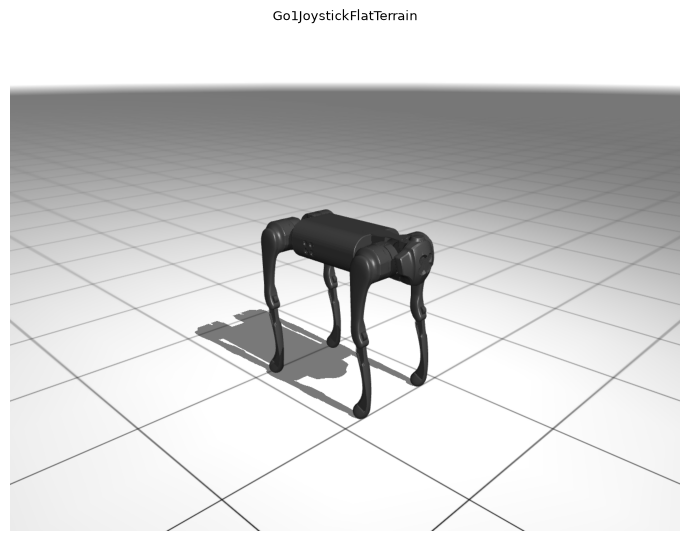

In [17]:
from rl_locomotion.eval import figures as fig

env = pg_registry.load("Go1JoystickFlatTerrain")
shot = fig.hero_shot(env, width=1200, height=900)
print(shot.shape)
rr.gallery([shot], ["Go1JoystickFlatTerrain"], ncols=1, figsize_per_tile=7);


## Choosing the camera

Lower `zoom` fills more of the frame:


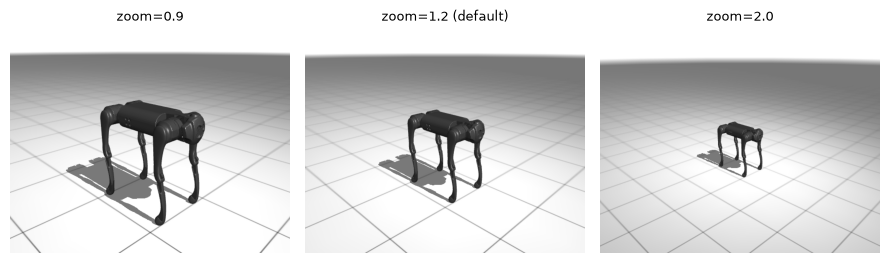

In [18]:
shots = [fig.hero_shot(env, width=600, height=480, zoom=z) for z in (0.9, 1.2, 2.0)]
rr.gallery(shots, ["zoom=0.9", "zoom=1.2 (default)", "zoom=2.0"], ncols=3);


### Several angles at once



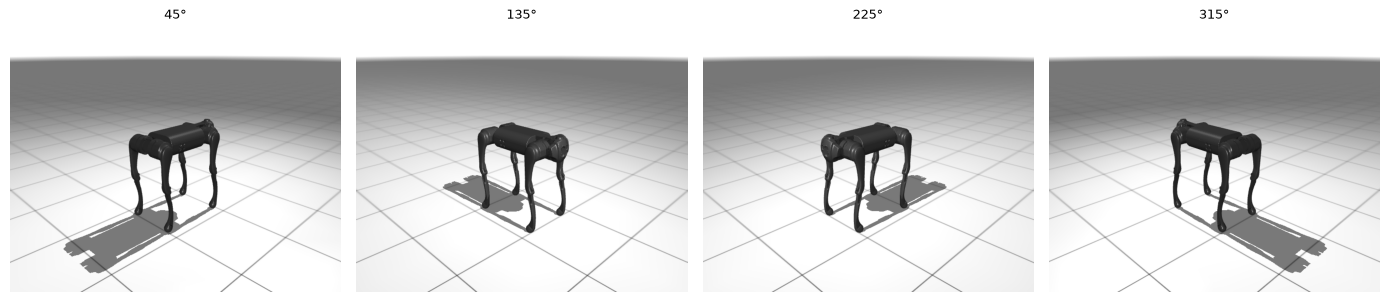

In [19]:
views = fig.orbit(env, n_views=4, width=700, height=560)
rr.gallery(views, [f"{45 + i * 90}°" for i in range(4)], ncols=4,
           figsize_per_tile=3.5);


## All nine robots in one figure




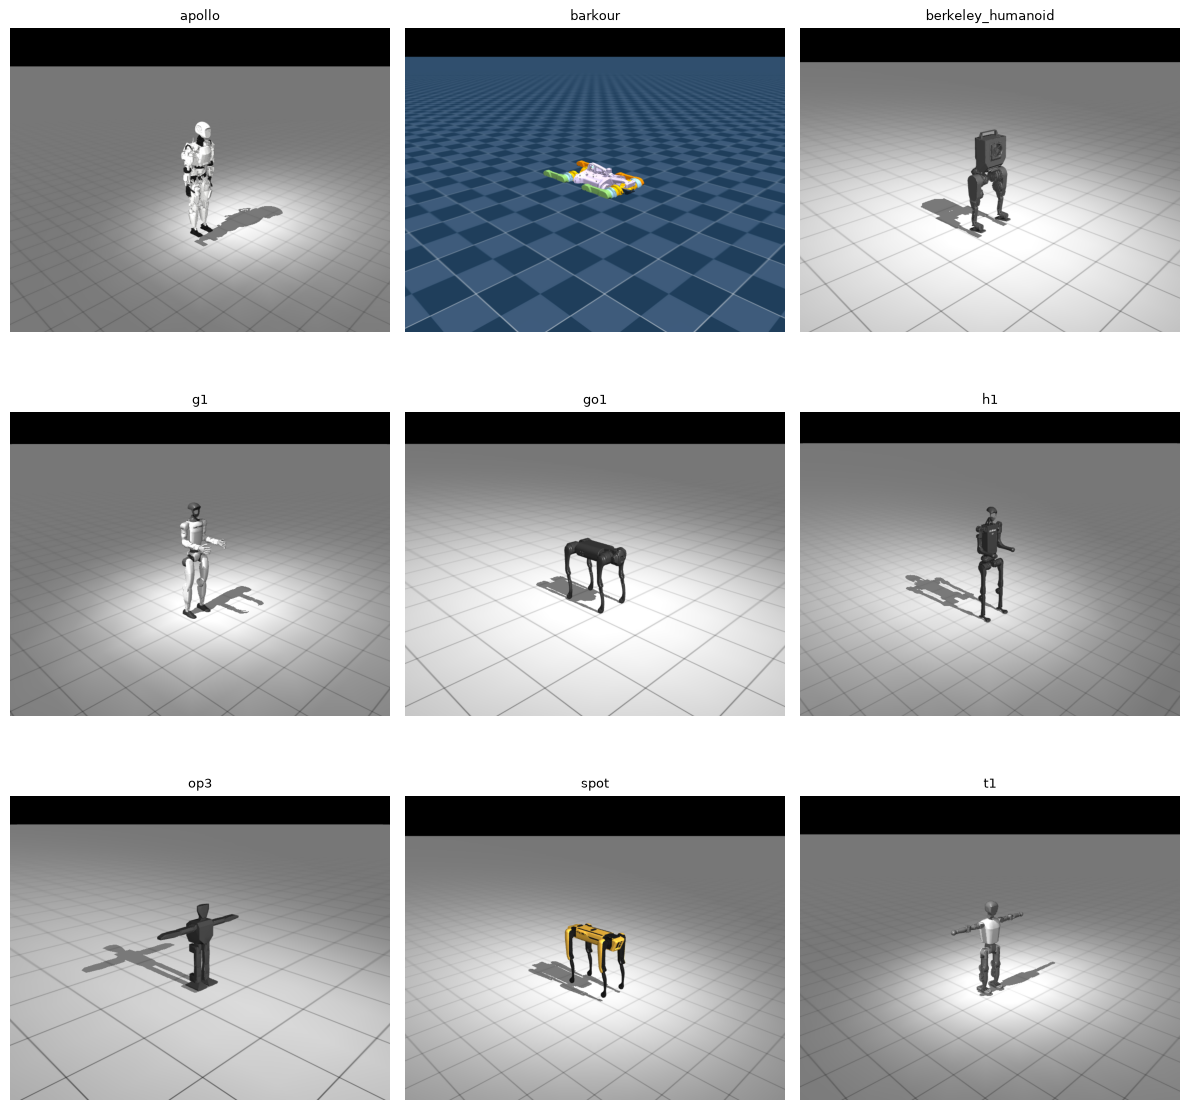

In [20]:
from pathlib import Path

ROOT = Path.cwd().parents[1]          # notebooks/local -> RL-for-Locomotion
out = ROOT / "experiments/figures/robot_lineup.png"
out.parent.mkdir(parents=True, exist_ok=True)
plate = fig.robot_lineup(zoom=2.0, skybox=False, reflections=False);
plate.savefig(out, dpi=200, bbox_inches="tight")

---

## Every environment, rendered

The gallery earlier showed one robot per *platform*. This renders all 19
locomotion **environments.

Two details make this honest rather than decorative:

- **`reset()`, not the model's default pose.** `Go1Getup` starts with the
  robot lying on its back; the default pose would show it standing. The
  seed is fixed so the figures are reproducible.
- **A lighting floor.** The rough-terrain scenes define no headlight of
  their own and use a dark rock texture, so they print far darker than the
  flat scenes. `headlight=(0.8, 0.2)` raises dim scenes to match the others
  and never dims a scene that was already lit correctly.




19 environments


Module ccd_kernel_builder__locals__ccd_kernel_5ece9a74 2f888b8 load on device 'cpu' took 1.76 ms  (cached)


Module _primitive_narrowphase__locals__primitive_narrowphase_c14eff27 04fb268 load on device 'cpu' took 2.29 ms  (cached)
Module _friction_dof__locals__kernel_b54a4577 e37bf78 load on device 'cpu' took 0.69 ms  (cached)
Module _limit_slide_hinge__locals__kernel_37504ae5 09ccafe load on device 'cpu' took 0.16 ms  (cached)
Module _efc_contact_init__locals__kernel_9582211b 9fcf080 load on device 'cpu' took 0.35 ms  (cached)
Module _efc_contact_jac_sparse__locals__kernel_60646703 3fb729f load on device 'cpu' took 0.43 ms  (cached)
Module _tile_cholesky_factorize_solve_block__locals__kernel_bf4cf040 8e53cc5 load on device 'cpu' took 0.48 ms  (cached)
Module _solve_init_dof__locals__kernel_ef1943e8 44f4008 load on device 'cpu' took 0.30 ms  (cached)
Module _solve_init_jaref_kernel__locals__kernel_4847e062 9add902 load on device 'cpu' took 0.27 ms  (cached)
Module _update_constraint_init_qfrc_constraint_sparse__locals__kernel_75c6b7f4 6be0bfb load on device 'cpu' took 0.40 ms  (cached)
Module

Module _update_gradient_JTDAJ_dense_tiled__locals__kernel_acd5a22b 727b938 load on device 'cpu' took 0.85 ms  (cached)


Module _update_gradient_JTDAJ_dense_tiled__locals__kernel_875d2cd0 843a6db load on device 'cpu' took 0.82 ms  (cached)


...

Module _tile_cholesky_factorize_solve_block__locals__kernel_f3342cb3 a103ccf load on device 'cpu' took 1.39 ms  (cached)
Module _solve_init_jaref_kernel__locals__kernel_7e8aba1f 76e9fa5 load on device 'cpu' took 0.19 ms  (cached)
Module _update_gradient_JTDAJ_dense_tiled__locals__kernel_82c2e99d b1602f8 load on device 'cpu' took 0.30 ms  (cached)
Module _update_gradient_cholesky__locals__kernel_b3f743a5 67da6f7 load on device 'cpu' took 0.12 ms  (cached)
Module _update_gradient_cholesky__locals__kernel_9d8530a9 2b9252f load on device 'cpu' took 0.13 ms  (cached)


Module ccd_kernel_builder__locals__ccd_kernel_8537faaa a75d72f load on device 'cpu' took 2.46 ms  (cached)
Module _tile_cholesky_factorize_solve_block__locals__kernel_e895c715 10c63c3 load on device 'cpu' took 0.55 ms  (cached)
Module _solve_init_jaref_kernel__locals__kernel_525353fc 2c81528 load on device 'cpu' took 0.45 ms  (cached)
Module _update_gradient_JTDAJ_dense_tiled__locals__kernel_e165fff1 9db11db load on device 'cpu' took 0.15 ms  (cached)
Module _update_gradient_cholesky__locals__kernel_9d181296 bc6c57a load on device 'cpu' took 0.26 ms  (cached)
Module _update_gradient_cholesky__locals__kernel_fa93b111 e8a2735 load on device 'cpu' took 0.16 ms  (cached)


Module _update_gradient_JTDAJ_dense_tiled__locals__kernel_983ee6f4 148c7c7 load on device 'cpu' took 2.22 ms  (cached)


Module _tile_cholesky_factorize_solve_block__locals__kernel_15a1f798 73d1abf load on device 'cpu' took 1.27 ms  (cached)
Module _solve_init_jaref_kernel__locals__kernel_fece782e 51eb38d load on device 'cpu' took 0.28 ms  (cached)
Module _update_gradient_JTDAJ_dense_tiled__locals__kernel_0a75c1d5 950340c load on device 'cpu' took 0.34 ms  (cached)
Module _update_gradient_cholesky__locals__kernel_ffaeacca d460ed0 load on device 'cpu' took 0.54 ms  (cached)
Module _update_gradient_cholesky__locals__kernel_1b5c3bb6 83ef424 load on device 'cpu' took 0.41 ms  (cached)


Module ccd_hfield_kernel_builder__locals__ccd_hfield_kernel_a193a6f6 4137e91 load on device 'cpu' took 1.71 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_2da0f92a 27e7481 load on device 'cpu' took 1.43 ms  (cached)


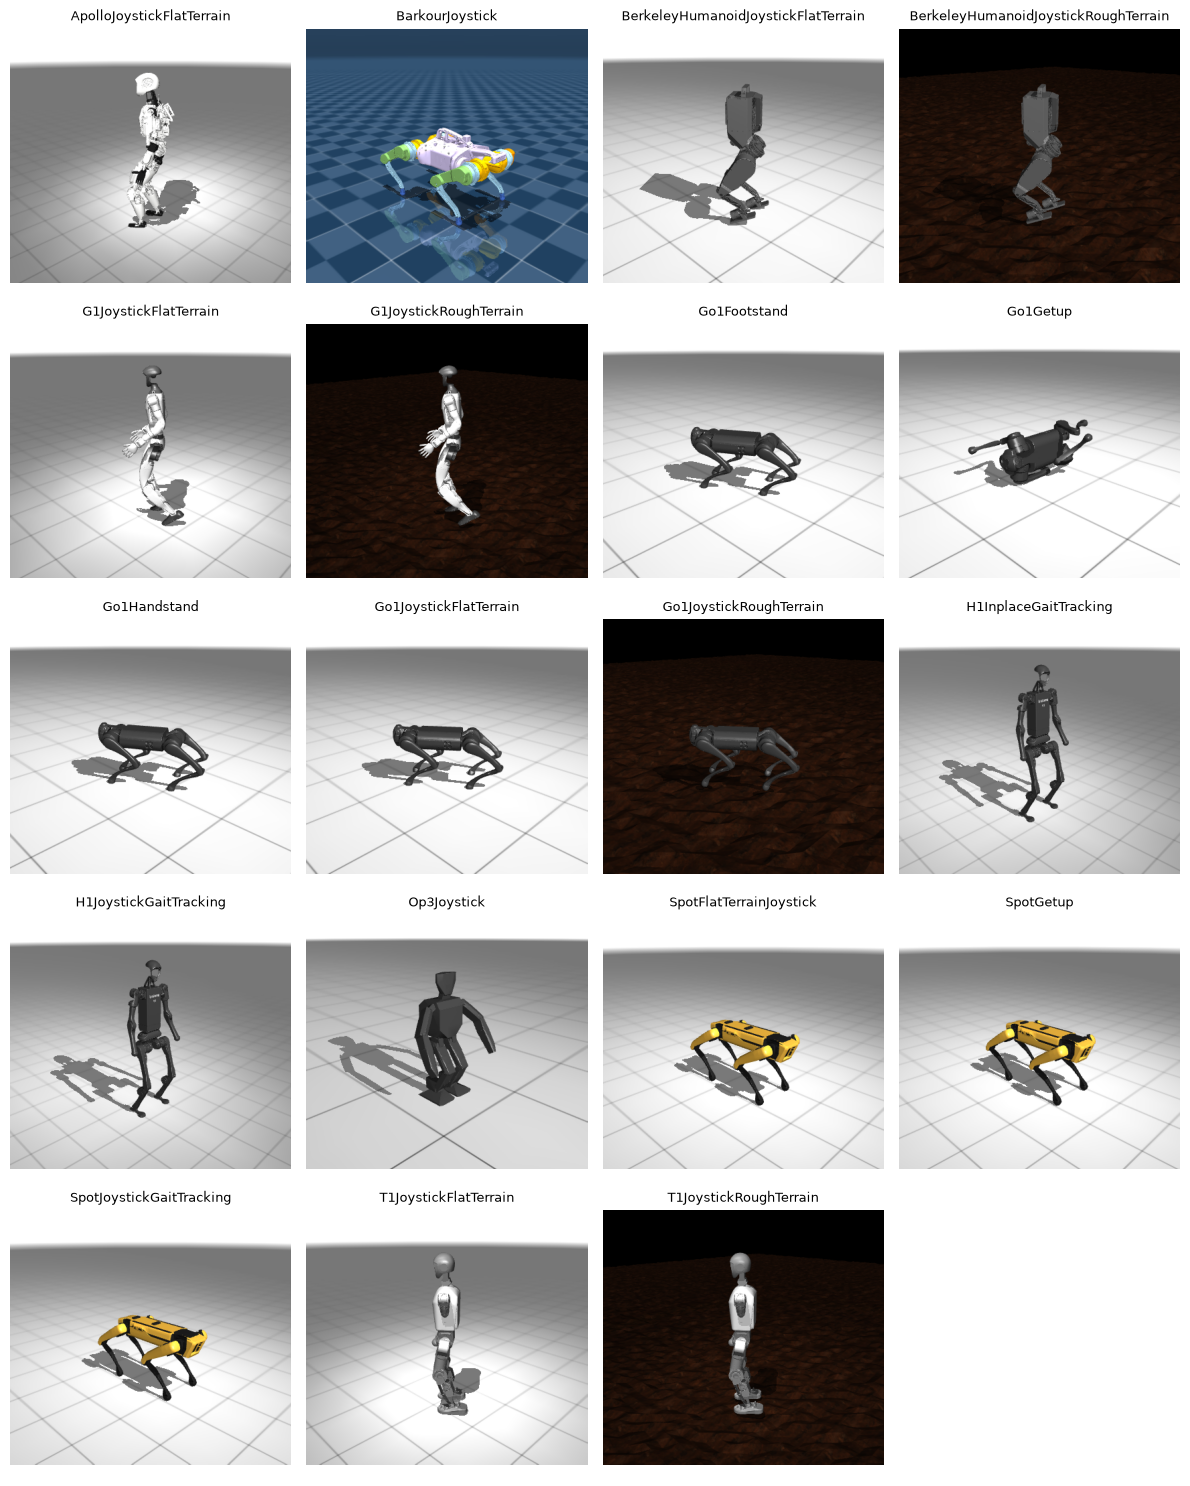

In [21]:
from rl_locomotion.eval.figures import reset_state

loco = reg.envs_table("locomotion").index.tolist()
print(len(loco), "environments")

frames = []
for name in loco:
    e = pg_registry.load(name)
    frames.append(fig.hero_shot(e, reset_state(e), width=420, height=380,
                                headlight=(0.8, 0.2)))

rr.gallery(frames, loco, ncols=4, figsize_per_tile=3.0);


### Flat vs rough terrain



saved -> /Users/elena/Desktop/reinforcement-learnig-dipl/RL-for-Locomotion/experiments/figures/go1_flat_vs_rough.png


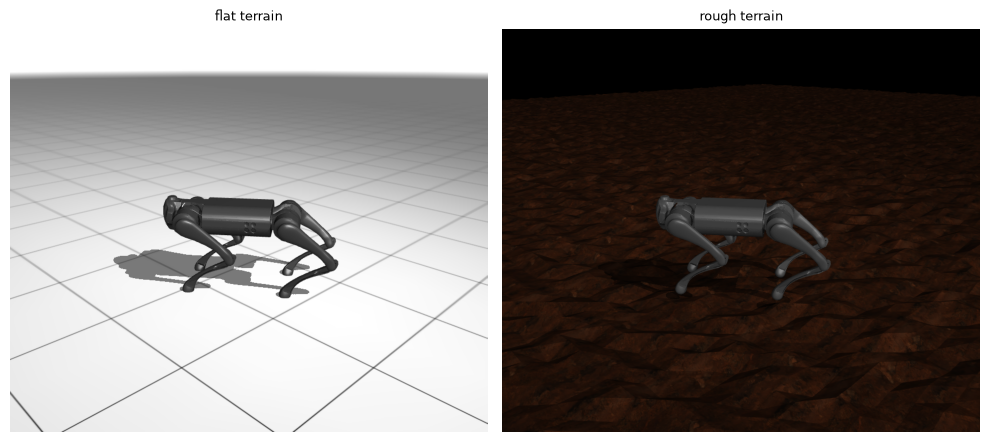

In [23]:
import os
from pathlib import Path

import rl_locomotion
from rl_locomotion.eval.figures import reset_state

# The notebook runs from notebooks/local/, so resolve the repo root from
# the installed package rather than a relative path.
REPO = Path(rl_locomotion.__file__).resolve().parents[2]
EXPERIMENTS = Path(os.environ.get("RL_EXPERIMENTS_DIR", REPO / "experiments"))

PAIR = ["Go1JoystickFlatTerrain", "Go1JoystickRoughTerrain"]
TITLES = ["flat terrain", "rough terrain"]

frames = []
for name in PAIR:
    e = pg_registry.load(name)
    frames.append(fig.hero_shot(e, reset_state(e), width=900, height=760,
                                headlight=(0.8, 0.2)))

figure = rr.gallery(frames, TITLES, ncols=2, figsize_per_tile=5.0)

out_path = EXPERIMENTS / "figures" / "go1_flat_vs_rough.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
figure.savefig(out_path, dpi=200, bbox_inches="tight")
print("saved ->", out_path)


In [24]:
from rl_locomotion.envs import terrain

hmap = terrain.height_map(pg_registry.load("Go1JoystickRoughTerrain"))
hmap.summary()


{'grid': '256x256',
 'area_m': '20x20',
 'cell_size_m': 0.0781,
 'peak_to_peak_m': 0.05,
 'roughness_std_m': 0.0145}